# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [55]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [56]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [57]:
# Use shape function to return dimensions as a tuple
mpg_dimensions = mpg_data.shape
print(f"There are {mpg_dimensions[0]} rows and {mpg_dimensions[1]} variables (columns)")

There are 392 rows and 9 variables (columns)


_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [110]:
# Get data types
mpg_data.dtypes

print("MPG (miles per gallon) is the response variable of the data set. It is stored as a float (float 64), a number with decimal points.")

MPG (miles per gallon) is the response variable of the data set. It is stored as a float (float 64), a number with decimal points.


_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [111]:
#Sort dataframe by horsepower in descending value
mpg_data_sorted = mpg_data.sort_values(by="horsepower", ascending=0)

#Return top 5 rows
mpg_data_sorted.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala


_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [77]:
number_predictors = mpg_dimensions[1] -1

print(f"There are {number_predictors} predictor variables")

There are 8 predictor variables


You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

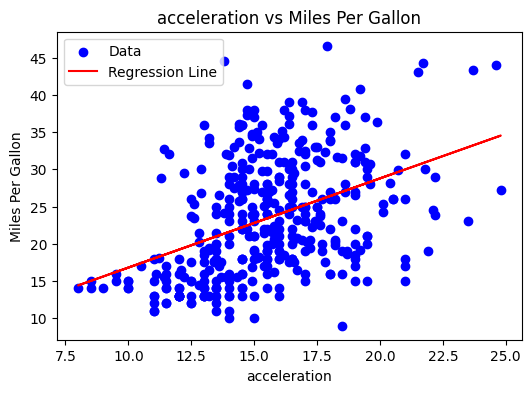

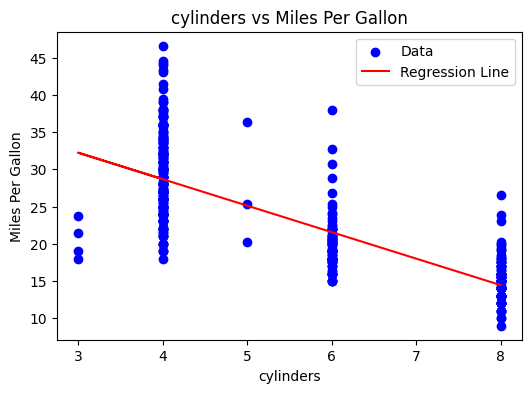

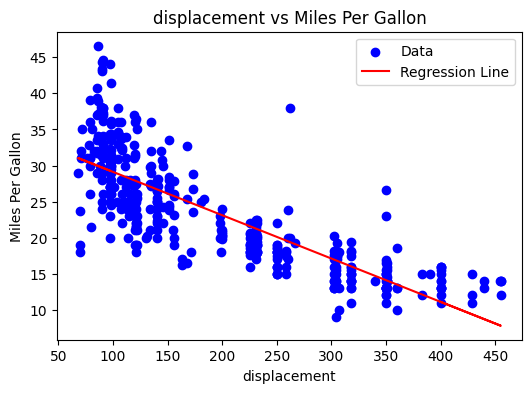

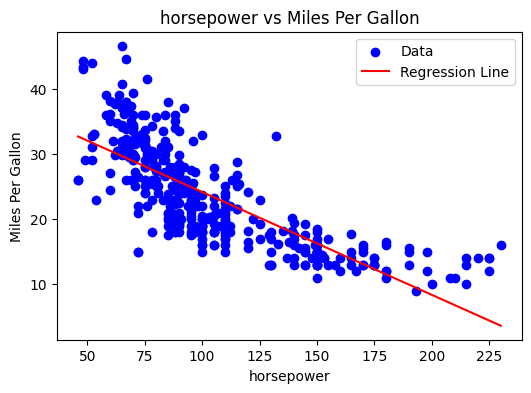

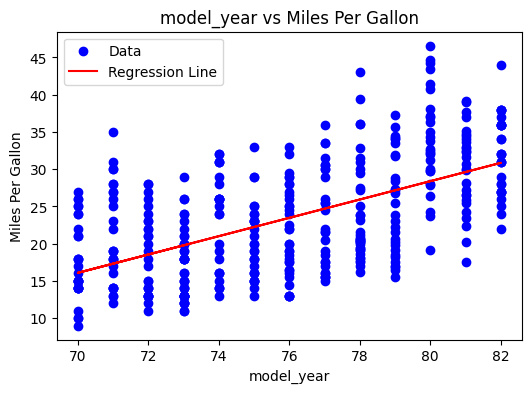

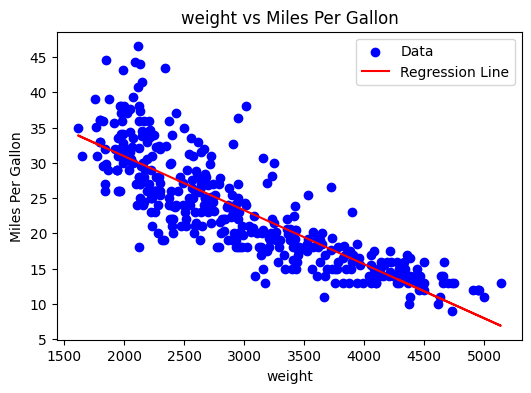

In [112]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='blue')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='red', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

Acceleration vs MPG is positive (higher acceleration associated with higher mpg)
Cylinders vs MPG is negative (higher # of cylinders associated with lower mpg)
Displacement vs MPG is positive (higher displacement associated with higher mpg)
Horsepower vs MPG is negative (higher horsepower associated with lower mpg)
Model Year vs MPG is positive (higher model year associated with higher mpg)
Weight vs MPG is negative (higher weight associated with lower mpg)

_(ii)_ What concept ‘defines’ the plotted line?

In linear regression, the plotted line, or line of best fit, is defined by two coefficients b0 and b1. b0 is the intercept (mpg when predictor variable is 0, "base value") and b1 is the slope (change to mpg per unit change of the predictor variable)

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

No. The plotted line is designed to minimize the difference between the observed data and the prediction (mimize RMSE). Deviations can indicate several things such as if a specific data point is an outlier (if one data point has an especially large deviation from the line) or that the response variable is affected by multiple variables so the relationship between the variables is not actually linear.

#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [113]:
mpg_train, mpg_test = train_test_split(mpg_data, train_size=0.75,random_state=42)

mpg_train

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
70,13.0,8,400.0,190.0,4422,12.5,72,usa,chrysler newport royal
158,16.0,8,318.0,150.0,4498,14.5,75,usa,plymouth grand fury
37,18.0,6,232.0,100.0,3288,15.5,71,usa,amc matador
25,10.0,8,360.0,215.0,4615,14.0,70,usa,ford f250
...,...,...,...,...,...,...,...,...,...
115,15.0,8,350.0,145.0,4082,13.0,73,usa,chevrolet monte carlo s
361,25.4,6,168.0,116.0,2900,12.6,81,japan,toyota cressida
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10
346,32.3,4,97.0,67.0,2065,17.8,81,japan,subaru


**Step 2: Fit the linear regression model.**

In [114]:
# fit the linear regression model to the training data
lm  = LinearRegression()
numeric_predictors = mpg_train[["cylinders", "displacement","horsepower","weight", "acceleration", "model_year","weight"]]
y = mpg_train["mpg"]

lm.fit(
    numeric_predictors,
    y
)

# Create a DataFrame containing the slope (coefficients) and intercept
coefficients_df = pd.DataFrame({
    "predictor": numeric_predictors.columns,
    "slope": lm.coef_,
    "intercept": [lm.intercept_] * len(lm.coef_)
})

# Display the coefficients DataFrame
print(coefficients_df)

# lm.coef_ gives the coefficients for each predictor (change in miles per gallon per unit change in each predictor variable)
# lm.intercept_ gives the intercept b_0 (the predicted miles per gallon when all predictors are set to 0)

      predictor     slope  intercept
0     cylinders -0.611980  -12.00551
1  displacement  0.007957  -12.00551
2    horsepower -0.005012  -12.00551
3        weight -0.003139  -12.00551
4  acceleration  0.034705  -12.00551
5    model_year  0.733816  -12.00551
6        weight -0.003139  -12.00551


#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [109]:
# Add predicted values to test data df
mpg_test["predicted"] = lm.predict(mpg_test[["cylinders", "displacement","horsepower","weight", "acceleration", "model_year", "weight"]])

#Calculate RMSPE
lm_mult_test_RMSPE = mean_squared_error(
    y_true=mpg_test["mpg"],
    y_pred=mpg_test["predicted"]
)**(1/2)

lm_mult_test_RMSPE

3.7433423403576103

# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 25/05/2026`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dsf1-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
